<a href="https://colab.research.google.com/github/JamesJokDutAkuei/ML-Models/blob/main/OnlineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OULAD STUDENT PERFORMANCE PREDICTION

##Comparing Traditional ML vs Deep Learning Approaches

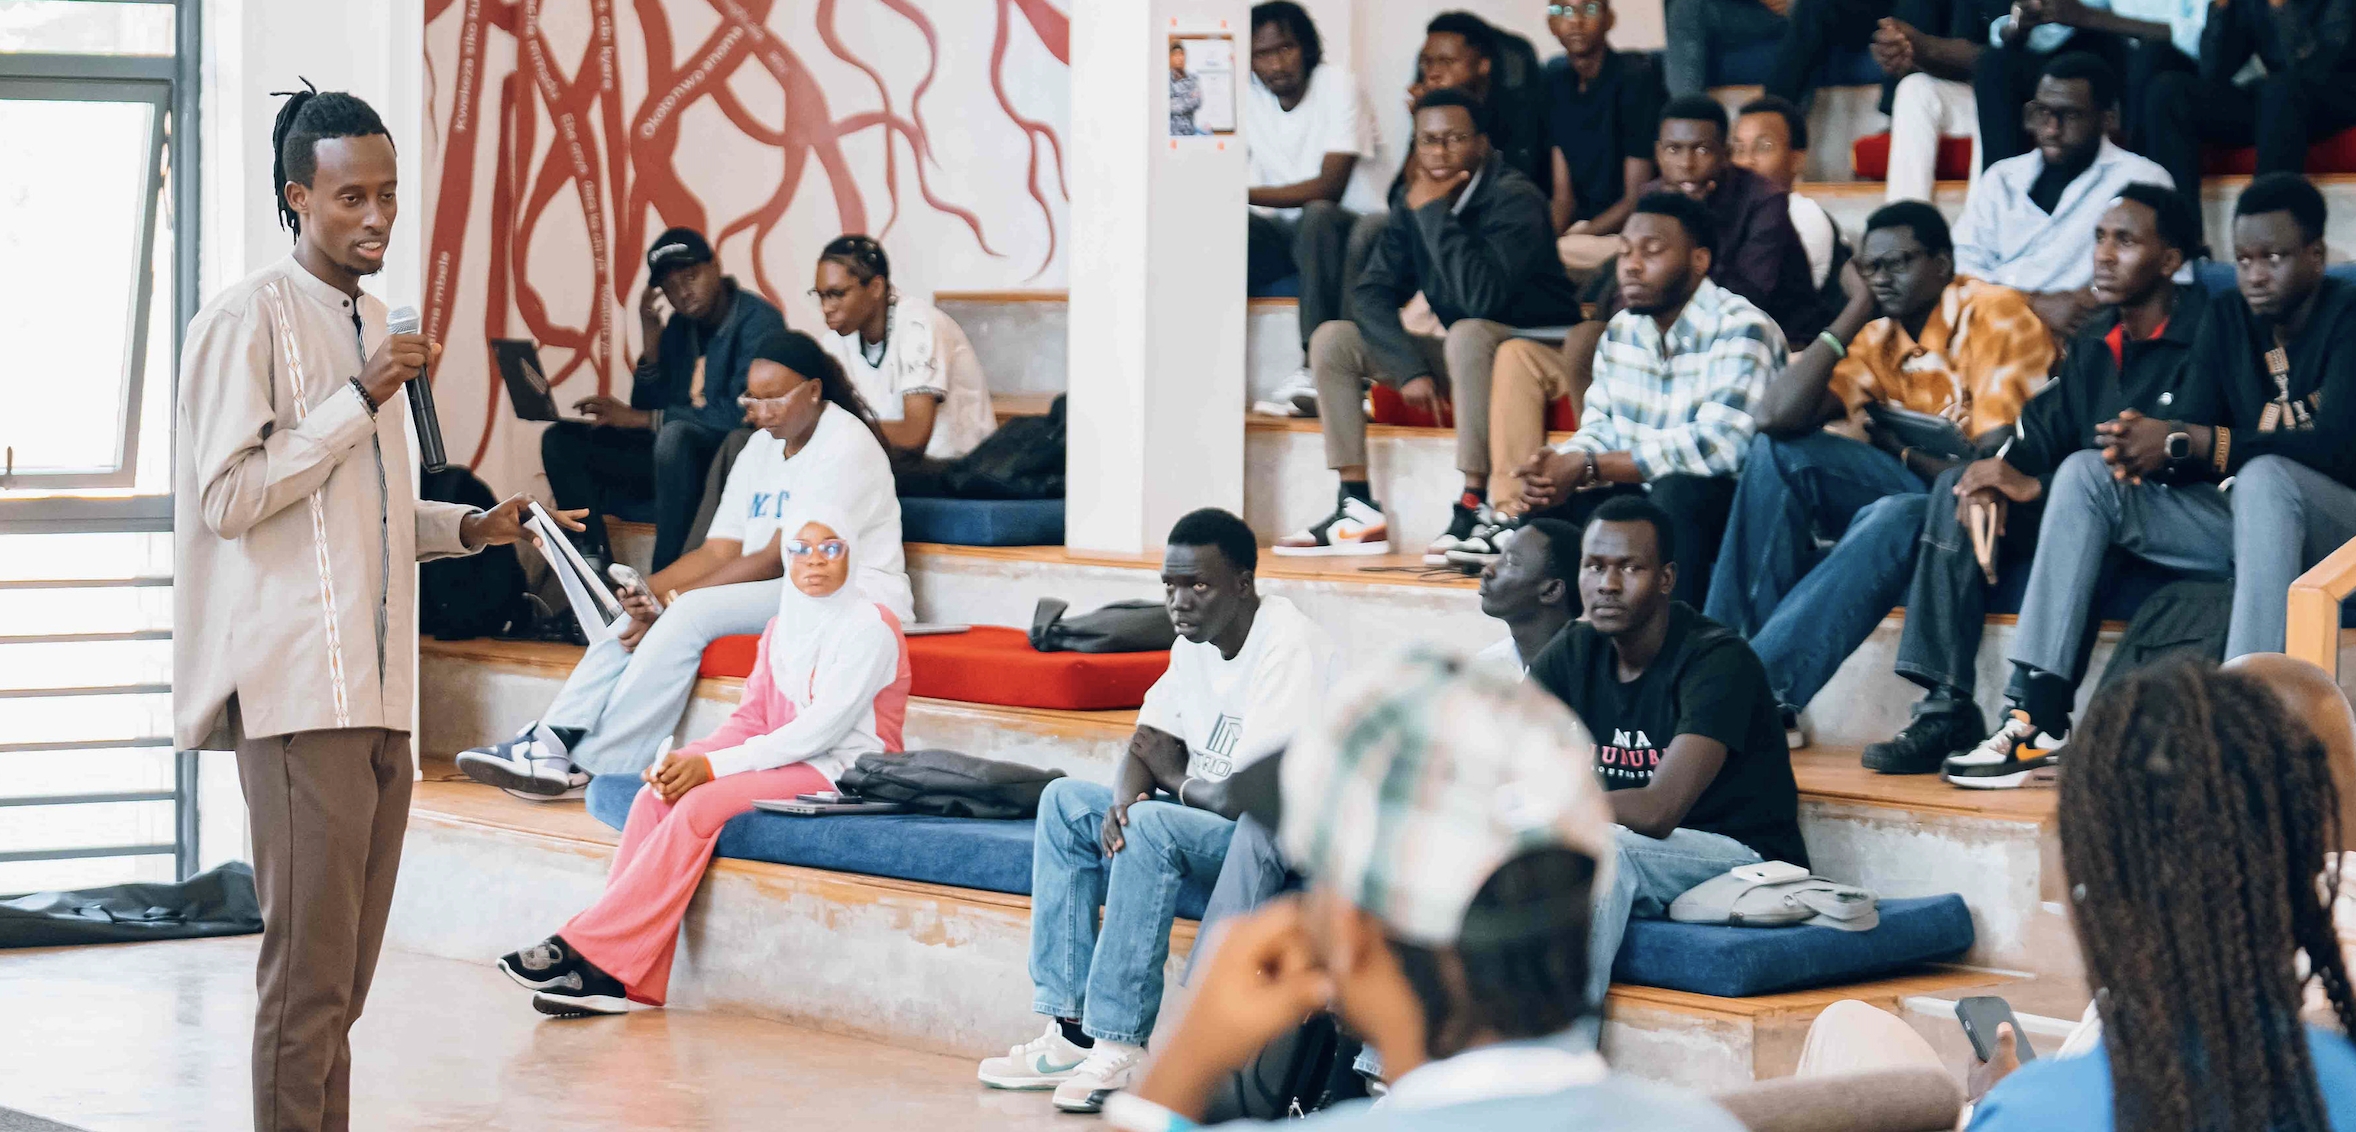

Author: James Jok Dut Akuei

Dataset: Open University Learning Analytics Dataset (OULAD)

Problem: Predict student pass/fail from learning behavior patterns

# =============================================================================================
# PART 1: INSTALL & IMPORT LIBRARIES

In [ ]:
print("="*80)
print("📦 INSTALLING REQUIRED PACKAGES...")
print("="*80)

# Install packages (only needed first time)
!pip install -q kagglehub pandas numpy scikit-learn xgboost tensorflow matplotlib seaborn imbalanced-learn

print("✅ All packages installed!\n")

# Import libraries
import sklearn
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            classification_report, roc_curve)
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from imblearn.over_sampling import SMOTE, RandomOverSampler
import warnings
import time
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully!")
print(f"📌 TensorFlow version: {tf.__version__}")
print(f"📌 Scikit-learn version: {sklearn.__version__}\n")

📦 INSTALLING REQUIRED PACKAGES...
✅ All packages installed!

✅ All libraries imported successfully!
📌 TensorFlow version: 2.19.0
📌 Scikit-learn version: 1.6.1



# PART 2: DOWNLOAD & LOAD OULAD DATA

In [ ]:
print("="*80)
print("📥 DOWNLOADING OULAD DATASET FROM KAGGLE...")
print("="*80)

# Download OULAD dataset
path = kagglehub.dataset_download("anlgrbz/student-demographics-online-education-dataoulad")
print(f"✅ Dataset downloaded to: {path}\n")

# Load all OULAD CSV files
print("📂 Loading OULAD CSV files...")

student_info = pd.read_csv(f"{path}/studentInfo.csv")
student_vle = pd.read_csv(f"{path}/studentVle.csv")
student_assessment = pd.read_csv(f"{path}/studentAssessment.csv")
assessments = pd.read_csv(f"{path}/assessments.csv")
vle = pd.read_csv(f"{path}/vle.csv")
courses = pd.read_csv(f"{path}/courses.csv")

print(f"✅ Student Info: {student_info.shape}")
print(f"✅ Student VLE: {student_vle.shape}")
print(f"✅ Student Assessment: {student_assessment.shape}")
print(f"✅ Assessments: {assessments.shape}")
print(f"✅ VLE: {vle.shape}")
print(f"✅ Courses: {courses.shape}")

print(f"\n🎉 SUCCESS! Loaded OULAD dataset")
print(f"   📊 Total students: {student_info['id_student'].nunique():,}")
print(f"   📊 Total VLE interactions: {len(student_vle):,}")
print(f"   📊 Total assessments: {len(student_assessment):,}\n")

📥 DOWNLOADING OULAD DATASET FROM KAGGLE...


100%|██████████| 42.2M/42.2M [00:03<00:00, 14.6MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1

📂 Loading OULAD CSV files...
✅ Student Info: (32593, 12)
✅ Student VLE: (10655280, 6)
✅ Student Assessment: (173912, 5)
✅ Assessments: (206, 6)
✅ VLE: (6364, 6)
✅ Courses: (22, 3)

🎉 SUCCESS! Loaded OULAD dataset
   📊 Total students: 28,785
   📊 Total VLE interactions: 10,655,280
   📊 Total assessments: 173,912



# PART 3: EXPLORATORY DATA ANALYSIS (EDA)


📊 EXPLORATORY DATA ANALYSIS

👀 Sample Student Info:
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N        

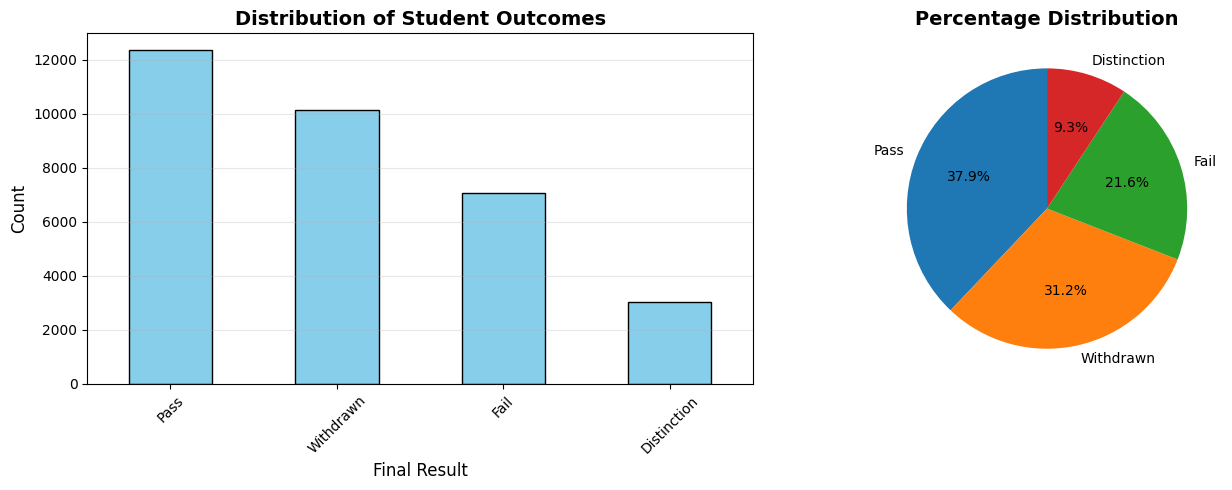


🔍 MISSING VALUES CHECK:
imd_band    1111
dtype: int64


In [ ]:
print("="*80)
print("📊 EXPLORATORY DATA ANALYSIS")
print("="*80)

# Display sample data
print("\n👀 Sample Student Info:")
print(student_info.head())

print("\n👀 Sample VLE Interactions:")
print(student_vle.head())

print("\n👀 Sample Student Assessment:")
print(student_assessment.head())

# Check target variable distribution
print("\n🎯 TARGET VARIABLE DISTRIBUTION (final_result):")
print(student_info['final_result'].value_counts())
print(f"\nPercentages:")
print(student_info['final_result'].value_counts(normalize=True).round(3)*100)

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
student_info['final_result'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Student Outcomes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Final Result', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie plot
student_info['final_result'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Percentage Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Check missing values
print("\n🔍 MISSING VALUES CHECK:")
missing = student_info.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values in Student Info!")
else:
    print(missing[missing > 0])

# PART 4: FEATURE ENGINEERING


In [ ]:
print("\n" + "="*80)
print("🔧 FEATURE ENGINEERING FOR TRADITIONAL ML")
print("="*80)


🔧 FEATURE ENGINEERING FOR TRADITIONAL ML


### 4.1: VLE Engagement Features

In [ ]:
print("\n📊 Creating VLE engagement features...")

# Aggregate VLE interactions per student
vle_features = student_vle.groupby(['code_module', 'code_presentation', 'id_student']).agg({
    'sum_click': ['sum', 'mean', 'std', 'max', 'min'],
    'date': ['count', 'min', 'max']
}).reset_index()

# Flatten column names
vle_features.columns = ['code_module', 'code_presentation', 'id_student',
                        'total_clicks', 'avg_clicks', 'std_clicks', 'max_clicks', 'min_clicks',
                        'days_active', 'first_activity', 'last_activity']

# Fill NaN in std_clicks (for students with single interaction)
vle_features['std_clicks'].fillna(0, inplace=True)

# Calculate derived features
vle_features['clicks_per_day'] = vle_features['total_clicks'] / (vle_features['days_active'] + 1)
vle_features['activity_span'] = vle_features['last_activity'] - vle_features['first_activity']
vle_features['engagement_consistency'] = vle_features['std_clicks'] / (vle_features['avg_clicks'] + 1)

print(f"✅ VLE features created: {vle_features.shape}")
print(f"   Features: total_clicks, avg_clicks, std_clicks, max_clicks, min_clicks,")
print(f"            days_active, clicks_per_day, activity_span, engagement_consistency")


📊 Creating VLE engagement features...
✅ VLE features created: (29228, 14)
   Features: total_clicks, avg_clicks, std_clicks, max_clicks, min_clicks,
            days_active, clicks_per_day, activity_span, engagement_consistency


### 4.2: Assessment Features


In [ ]:
print("\n📝 Creating assessment features...")

# Aggregate assessment scores per student
assessment_features = student_assessment.groupby('id_student').agg({
    'score': ['mean', 'std', 'min', 'max', 'count'],
    'date_submitted': ['mean', 'std']
}).reset_index()

# Flatten column names
assessment_features.columns = ['id_student',
                               'avg_score', 'std_score', 'min_score', 'max_score', 'num_assessments',
                               'avg_submission_day', 'std_submission_day']

# Fill NaN (students who didn't submit or single submission)
assessment_features.fillna(0, inplace=True)

print(f"✅ Assessment features created: {assessment_features.shape}")
print(f"   Features: avg_score, std_score, min_score, max_score, num_assessments,")
print(f"            avg_submission_day, std_submission_day")


📝 Creating assessment features...
✅ Assessment features created: (23369, 8)
   Features: avg_score, std_score, min_score, max_score, num_assessments,
            avg_submission_day, std_submission_day


### 4.3: Merge All Features

In [ ]:
print("\n🔗 Merging all features...")

# Start with student info
df = student_info.copy()

# Merge VLE features
df = df.merge(vle_features,
              on=['code_module', 'code_presentation', 'id_student'],
              how='left')

# Merge assessment features
df = df.merge(assessment_features,
              on='id_student',
              how='left')

# Fill missing values (students with no VLE or assessment data)
df.fillna(0, inplace=True)

print(f"✅ Final dataset shape: {df.shape}")
print(f"✅ Total features: {len(df.columns)}")


🔗 Merging all features...
✅ Final dataset shape: (32593, 30)
✅ Total features: 30


### 4.4: Create Binary Target Variable

In [ ]:
print("\n🎯 Creating binary target variable...")

# Binary classification: Pass (including Distinction) vs Fail/Withdrawn
df['target'] = df['final_result'].apply(
    lambda x: 1 if x in ['Pass', 'Distinction'] else 0
)

print("✅ Target encoding:")
print("   1 = Pass/Distinction (Success)")
print("   0 = Fail/Withdrawn (At-risk)")
print(f"\n📊 Class distribution:")
print(df['target'].value_counts())
print(f"\nPercentages:")
print(df['target'].value_counts(normalize=True).round(3)*100)


🎯 Creating binary target variable...
✅ Target encoding:
   1 = Pass/Distinction (Success)
   0 = Fail/Withdrawn (At-risk)

📊 Class distribution:
target
0    17208
1    15385
Name: count, dtype: int64

Percentages:
target
0    52.8
1    47.2
Name: proportion, dtype: float64


# PART 5: DATA PREPROCESSING

In [ ]:
print("\n" + "="*80)
print("🧹 DATA PREPROCESSING")
print("="*80)


🧹 DATA PREPROCESSING


### 5.1: Select Features


In [ ]:
print("\n✂️ Selecting features for modeling...")

# Demographic features
demographic_features = ['gender', 'region', 'highest_education',
                       'imd_band', 'age_band', 'num_of_prev_attempts',
                       'studied_credits', 'disability']

# VLE engagement features
vle_engagement_features = ['total_clicks', 'avg_clicks', 'std_clicks', 'max_clicks', 'min_clicks',
                          'days_active', 'first_activity', 'last_activity',
                          'clicks_per_day', 'activity_span', 'engagement_consistency']

# Assessment features
assessment_score_features = ['avg_score', 'std_score', 'min_score', 'max_score',
                            'num_assessments', 'avg_submission_day', 'std_submission_day']

# All features
feature_columns = demographic_features + vle_engagement_features + assessment_score_features

print(f"✅ Total features selected: {len(feature_columns)}")
print(f"   📌 Demographic: {len(demographic_features)}")
print(f"   📌 VLE Engagement: {len(vle_engagement_features)}")
print(f"   📌 Assessment: {len(assessment_score_features)}")


✂️ Selecting features for modeling...
✅ Total features selected: 26
   📌 Demographic: 8
   📌 VLE Engagement: 11
   📌 Assessment: 7


### 5.2: Encode Categorical Variables

In [ ]:
print("\n🔤 Encoding categorical variables...")

df_encoded = df.copy()

# One-hot encoding for categorical features
categorical_cols = ['gender', 'region', 'highest_education', 'imd_band',
                   'age_band', 'disability']

df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

print(f"✅ After one-hot encoding: {df_encoded.shape}")

# Get encoded feature columns
encoded_feature_cols = [col for col in df_encoded.columns
                       if col not in ['id_student', 'code_module', 'code_presentation',
                                     'final_result', 'target', 'date_registration',
                                     'date_unregistration']]

print(f"✅ Total encoded features: {len(encoded_feature_cols)}")


🔤 Encoding categorical variables...
✅ After one-hot encoding: (32593, 55)
✅ Total encoded features: 50


### 5.3: Train-Validation-Test Split

In [ ]:
print("\n✂️ Splitting data (70% train, 15% validation, 15% test)...")

X = df_encoded[encoded_feature_cols]
y = df_encoded['target']

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"✅ Training set: {X_train.shape} | Target: {y_train.shape}")
print(f"✅ Validation set: {X_val.shape} | Target: {y_val.shape}")
print(f"✅ Test set: {X_test.shape} | Target: {y_test.shape}")

print("\n📊 Class distribution in splits:")
print(f"   Train: Class 0={sum(y_train==0)}, Class 1={sum(y_train==1)}")
print(f"   Val:   Class 0={sum(y_val==0)}, Class 1={sum(y_val==1)}")
print(f"   Test:  Class 0={sum(y_test==0)}, Class 1={sum(y_test==1)}")


✂️ Splitting data (70% train, 15% validation, 15% test)...
✅ Training set: (22815, 50) | Target: (22815,)
✅ Validation set: (4889, 50) | Target: (4889,)
✅ Test set: (4889, 50) | Target: (4889,)

📊 Class distribution in splits:
   Train: Class 0=12046, Class 1=10769
   Val:   Class 0=2581, Class 1=2308
   Test:  Class 0=2581, Class 1=2308


### 5.4: Handle Class Imbalance with SMOTE


In [ ]:
print("\n⚖️ Handling class imbalance with SMOTE...")

print(f"Before SMOTE: {dict(y_train.value_counts())}")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:  {dict(pd.Series(y_train_balanced).value_counts())}")
print(f"✅ Training set balanced: {X_train_balanced.shape}")


⚖️ Handling class imbalance with SMOTE...
Before SMOTE: {0: np.int64(12046), 1: np.int64(10769)}
After SMOTE:  {0: np.int64(12046), 1: np.int64(12046)}
✅ Training set balanced: (24092, 50)


### 5.5: Feature Scaling

In [ ]:
print("\n📏 Scaling features with StandardScaler...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled (mean=0, std=1)")



📏 Scaling features with StandardScaler...
✅ Features scaled (mean=0, std=1)


# =============================================================================================

# PART 6: TRADITIONAL ML EXPERIMENTS (5 EXPERIMENTS)

In [ ]:
print("\n" + "="*80)
print("🤖 TRADITIONAL MACHINE LEARNING EXPERIMENTS (5 EXPERIMENTS)")
print("="*80)


🤖 TRADITIONAL MACHINE LEARNING EXPERIMENTS (5 EXPERIMENTS)


In [ ]:
# Results storage
results = []

def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, model_name, hyperparams):
    """
    Train and evaluate a model, return results
    """
    print(f"\n{'='*70}")
    print(f"🔬 EXPERIMENT: {model_name}")
    print(f"{'='*70}")
    print(f"⚙️  Hyperparameters: {hyperparams}")

    # Training
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    # Probabilities for AUC
    if hasattr(model, 'predict_proba'):
        y_test_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_test_proba = y_test_pred

    # Calculate metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    auc = roc_auc_score(y_test, y_test_proba)

    # Print results
    print(f"\n📊 RESULTS:")
    print(f"   Train Accuracy:  {train_acc:.4f}")
    print(f"   Val Accuracy:    {val_acc:.4f}")
    print(f"   Test Accuracy:   {test_acc:.4f}")
    print(f"   Precision:       {precision:.4f}")
    print(f"   Recall:          {recall:.4f}")
    print(f"   F1-Score:        {f1:.4f}")
    print(f"   AUC-ROC:         {auc:.4f}")
    print(f"   Training Time:   {training_time:.2f}s")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    print(f"\n📈 Confusion Matrix:")
    print(f"   [[TN={cm[0,0]}, FP={cm[0,1]}]")
    print(f"    [FN={cm[1,0]}, TP={cm[1,1]}]]")

    # Store results
    result = {
        'Model': model_name,
        'Hyperparameters': hyperparams,
        'Train_Acc': train_acc,
        'Val_Acc': val_acc,
        'Test_Acc': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'AUC_ROC': auc,
        'Training_Time': f"{training_time:.2f}s"
    }

    return result, model, y_test_proba

### EXPERIMENT 1: Logistic Regression (Baseline)

In [ ]:
print("\n\n" + "🔬 "*20)
print("EXPERIMENT 1: LOGISTIC REGRESSION (BASELINE)")
print("🔬 "*20)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_result, lr_trained, lr_proba = evaluate_model(
    lr_model, X_train_scaled, y_train_balanced,
    X_val_scaled, y_val, X_test_scaled, y_test,
    "Experiment 1: Logistic Regression",
    "C=1.0, max_iter=1000, solver=lbfgs"
)
lr_result['Insights'] = "Fast baseline, linear decision boundary, interpretable coefficients"
results.append(lr_result)



🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 
EXPERIMENT 1: LOGISTIC REGRESSION (BASELINE)
🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 

🔬 EXPERIMENT: Experiment 1: Logistic Regression
⚙️  Hyperparameters: C=1.0, max_iter=1000, solver=lbfgs

📊 RESULTS:
   Train Accuracy:  0.9308
   Val Accuracy:    0.9249
   Test Accuracy:   0.9239
   Precision:       0.8884
   Recall:          0.9593
   F1-Score:        0.9225
   AUC-ROC:         0.9737
   Training Time:   0.19s

📈 Confusion Matrix:
   [[TN=2303, FP=278]
    [FN=94, TP=2214]]


### EXPERIMENT 2: Random Forest


In [ ]:
print("\n\n" + "🔬 "*20)
print("EXPERIMENT 2: RANDOM FOREST")
print("🔬 "*20)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_result, rf_trained, rf_proba = evaluate_model(
    rf_model, X_train_balanced, y_train_balanced,
    X_val, y_val, X_test, y_test,
    "Experiment 2: Random Forest",
    "n_estimators=100, max_depth=20, min_samples_split=5"
)
rf_result['Insights'] = "Captures non-linear patterns, prone to overfitting, good feature importance"
results.append(rf_result)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': encoded_feature_cols,
    'importance': rf_trained.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🔝 TOP 15 MOST IMPORTANT FEATURES:")
print(feature_importance.head(15).to_string(index=False))



🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 
EXPERIMENT 2: RANDOM FOREST
🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 

🔬 EXPERIMENT: Experiment 2: Random Forest
⚙️  Hyperparameters: n_estimators=100, max_depth=20, min_samples_split=5

📊 RESULTS:
   Train Accuracy:  0.9875
   Val Accuracy:    0.9362
   Test Accuracy:   0.9350
   Precision:       0.9028
   Recall:          0.9662
   F1-Score:        0.9334
   AUC-ROC:         0.9804
   Training Time:   4.02s

📈 Confusion Matrix:
   [[TN=2341, FP=240]
    [FN=78, TP=2230]]

🔝 TOP 15 MOST IMPORTANT FEATURES:
               feature  importance
         last_activity    0.200898
         activity_span    0.143076
    avg_submission_day    0.135590
    std_submission_day    0.110224
           days_active    0.067521
       num_assessments    0.057733
             avg_score    0.054348
             max_score    0.034923
          total_clicks    0.033612
             std_score    0.032663
             min_score    0.021306
            max_clicks   

### EXPERIMENT 3: XGBoost

In [ ]:
print("\n\n" + "🔬 "*20)
print("EXPERIMENT 3: XGBOOST")
print("🔬 "*20)

# ✅ Helper function to clean column names for XGBoost
def clean_column_names(df):
    """Ensure all DataFrame column names are valid strings for XGBoost."""
    df.columns = [
        str(c).replace('[', '(').replace(']', ')').replace('<', '_')
        for c in df.columns
    ]
    return df

# ✅ Clean column names in all datasets
X_train_balanced = clean_column_names(X_train_balanced)
X_val = clean_column_names(X_val)
X_test = clean_column_names(X_test)

# ✅ Define and train the XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# ✅ Evaluate using your predefined function
xgb_result, xgb_trained, xgb_proba = evaluate_model(
    xgb_model,
    X_train_balanced, y_train_balanced,
    X_val, y_val, X_test, y_test,
    "Experiment 3: XGBoost",
    "n_estimators=100, lr=0.1, max_depth=5, subsample=0.8"
)

# ✅ Add result insights
xgb_result['Insights'] = "Gradient boosting, handles imbalance well, efficient training"
results.append(xgb_result)




🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 
EXPERIMENT 3: XGBOOST
🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 

🔬 EXPERIMENT: Experiment 3: XGBoost
⚙️  Hyperparameters: n_estimators=100, lr=0.1, max_depth=5, subsample=0.8

📊 RESULTS:
   Train Accuracy:  0.9559
   Val Accuracy:    0.9372
   Test Accuracy:   0.9339
   Precision:       0.9017
   Recall:          0.9653
   F1-Score:        0.9324
   AUC-ROC:         0.9819
   Training Time:   0.75s

📈 Confusion Matrix:
   [[TN=2338, FP=243]
    [FN=80, TP=2228]]


### EXPERIMENT 4: Random Forest with Feature Selection


In [ ]:
print("\n\n" + "🔬 "*20)
print("EXPERIMENT 4: RANDOM FOREST WITH FEATURE SELECTION")
print("🔬 "*20)

# Select top 25 features
top_n = 25
top_features = feature_importance.head(top_n)['feature'].tolist()
top_feature_indices = [encoded_feature_cols.index(f) for f in top_features]

print(f"✅ Selected top {top_n} features based on Random Forest importance")

# ✅ Create datasets with selected features (use iloc to slice DataFrames)
X_train_selected = X_train_balanced.iloc[:, top_feature_indices]
X_val_selected = X_val.iloc[:, top_feature_indices]
X_test_selected = X_test.iloc[:, top_feature_indices]

rf_selected_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=25,
    min_samples_split=3,
    random_state=42,
    n_jobs=-1
)

rf_selected_result, rf_selected_trained, rf_selected_proba = evaluate_model(
    rf_selected_model,
    X_train_selected, y_train_balanced,
    X_val_selected, y_val, X_test_selected, y_test,
    "Experiment 4: RF Feature Selected",
    f"top_{top_n}_features, n_estimators=150, max_depth=25"
)

rf_selected_result['Insights'] = (
    "Feature selection reduces overfitting, faster training, similar performance"
)
results.append(rf_selected_result)




🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 
EXPERIMENT 4: RANDOM FOREST WITH FEATURE SELECTION
🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 
✅ Selected top 25 features based on Random Forest importance

🔬 EXPERIMENT: Experiment 4: RF Feature Selected
⚙️  Hyperparameters: top_25_features, n_estimators=150, max_depth=25

📊 RESULTS:
   Train Accuracy:  0.9995
   Val Accuracy:    0.9393
   Test Accuracy:   0.9356
   Precision:       0.9059
   Recall:          0.9636
   F1-Score:        0.9339
   AUC-ROC:         0.9809
   Training Time:   8.64s

📈 Confusion Matrix:
   [[TN=2350, FP=231]
    [FN=84, TP=2224]]


### EXPERIMENT 5: XGBoost Optimized


In [ ]:
print("\n\n" + "🔬 "*20)
print("EXPERIMENT 5: XGBOOST OPTIMIZED")
print("🔬 "*20)

xgb_optimized_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.01,
    reg_lambda=1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_opt_result, xgb_opt_trained, xgb_opt_proba = evaluate_model(
    xgb_optimized_model, X_train_balanced, y_train_balanced,
    X_val, y_val, X_test, y_test,
    "Experiment 5: XGBoost Optimized",
    "n_est=200, lr=0.05, depth=7, subsample=0.9, colsample=0.8, gamma=0.1"
)
xgb_opt_result['Insights'] = "Hyperparameter tuning, regularization added, best traditional ML model"
results.append(xgb_opt_result)



🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 
EXPERIMENT 5: XGBOOST OPTIMIZED
🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 

🔬 EXPERIMENT: Experiment 5: XGBoost Optimized
⚙️  Hyperparameters: n_est=200, lr=0.05, depth=7, subsample=0.9, colsample=0.8, gamma=0.1

📊 RESULTS:
   Train Accuracy:  0.9714
   Val Accuracy:    0.9378
   Test Accuracy:   0.9335
   Precision:       0.9049
   Recall:          0.9601
   F1-Score:        0.9317
   AUC-ROC:         0.9825
   Training Time:   1.37s

📈 Confusion Matrix:
   [[TN=2348, FP=233]
    [FN=92, TP=2216]]


# =============================================================================================

# PART 7: DEEP LEARNING EXPERIMENTS (2 APPROACHES)

In [ ]:
print("\n" + "="*80)
print("🧠 DEEP LEARNING EXPERIMENTS (2 APPROACHES)")
print("="*80)


🧠 DEEP LEARNING EXPERIMENTS (2 APPROACHES)


### EXPERIMENT 6: Feedforward Neural Network (Sequential API)



🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 
EXPERIMENT 6: FEEDFORWARD NEURAL NETWORK
🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 
📐 Building Feedforward NN with Sequential API...

📋 Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,665 (69.00 KB)

 Trainable params: 17,281 (67.50 KB)

 Non-trainable params: 384 (1.50 KB)


🏋️ Training Feedforward NN...
Epoch 1/30
377/377 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8257 - auc: 0.9005 - loss: 0.3760 - val_accuracy: 0.9174 - val_auc: 0.9702 - val_loss: 0.2008 - learning_rate: 0.0010
Epoch 2/30
377/377 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9174 - auc: 0.9661 - loss: 0.2097 - val_accuracy: 0.9229 - val_auc: 0.9726 - val_loss: 0.1905 - learning_rate: 0.0010
Epoch 3/30
377/377 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9219 - auc: 0.9719 - loss: 0.1914 - val_accuracy: 0.9239 - val_auc: 0.9738 - val_loss: 0.1855 - learning_rate: 0.0010
Epoch 4/30
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9235 - auc: 0.9733 - loss: 0.1883 - val_accuracy: 0.9266 - val_auc: 0.9742 - val_loss: 0.1833 - learning_rate: 0.0010
Epoch 5/30
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9280 - auc: 0.9749 - loss: 0.1806 - val_accuracy: 0.9278 - val_auc: 0.9755 - val_loss: 0.1800 - learning_rate: 0.0010
Epoch 6/30
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

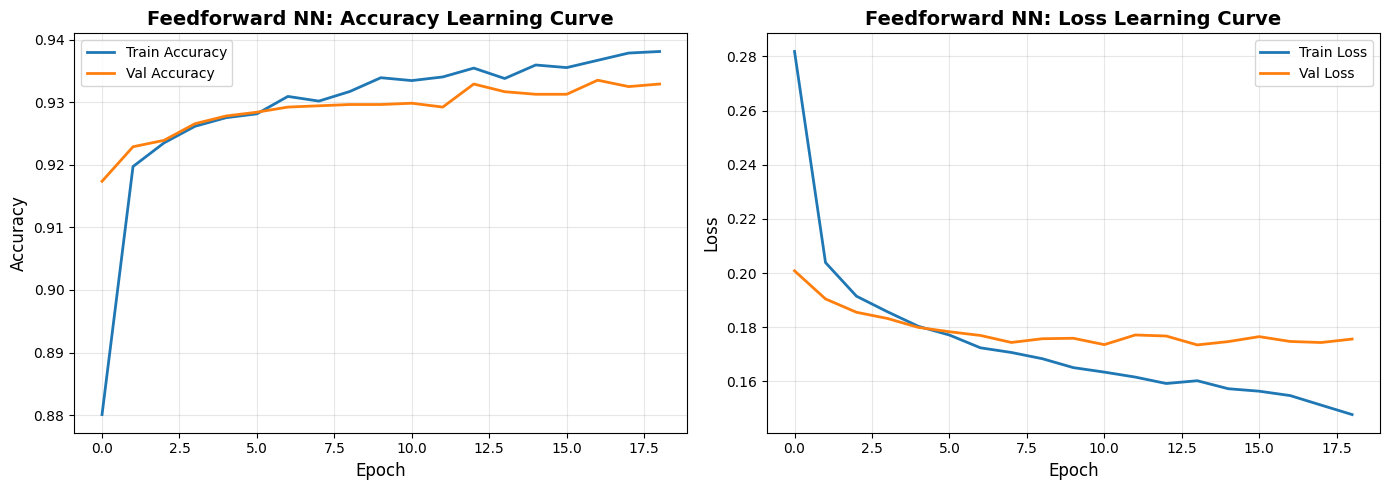

In [ ]:
print("\n\n" + "🔬 "*20)
print("EXPERIMENT 6: FEEDFORWARD NEURAL NETWORK")
print("🔬 "*20)

print("📐 Building Feedforward NN with Sequential API...")

# Build model
ffnn_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

ffnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

print("\n📋 Model Architecture:")
ffnn_model.summary()

# Train model
print("\n🏋️ Training Feedforward NN...")
start_time = time.time()

history_ffnn = ffnn_model.fit(
    X_train_scaled, y_train_balanced,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=64,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
    ]
)

training_time_ffnn = time.time() - start_time

print(f"\n✅ Training complete in {training_time_ffnn:.2f}s!")

# Evaluate
y_test_pred_ffnn = (ffnn_model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()
y_test_proba_ffnn = ffnn_model.predict(X_test_scaled, verbose=0).flatten()

train_loss, train_acc, train_auc = ffnn_model.evaluate(X_train_scaled, y_train_balanced, verbose=0)
val_loss, val_acc, val_auc = ffnn_model.evaluate(X_val_scaled, y_val, verbose=0)
test_loss, test_acc, test_auc = ffnn_model.evaluate(X_test_scaled, y_test, verbose=0)

# Print results
print(f"\n{'='*70}")
print(f"📊 FEEDFORWARD NN RESULTS:")
print(f"{'='*70}")
print(f"   Train Accuracy:  {train_acc:.4f}")
print(f"   Val Accuracy:    {val_acc:.4f}")
print(f"   Test Accuracy:   {test_acc:.4f}")
print(f"   Precision:       {precision_score(y_test, y_test_pred_ffnn):.4f}")
print(f"   Recall:          {recall_score(y_test, y_test_pred_ffnn):.4f}")
print(f"   F1-Score:        {f1_score(y_test, y_test_pred_ffnn):.4f}")
print(f"   AUC-ROC:         {roc_auc_score(y_test, y_test_proba_ffnn):.4f}")
print(f"   Training Time:   {training_time_ffnn:.2f}s")

cm_ffnn = confusion_matrix(y_test, y_test_pred_ffnn)
print(f"\n📈 Confusion Matrix:")
print(f"   [[TN={cm_ffnn[0,0]}, FP={cm_ffnn[0,1]}]")
print(f"    [FN={cm_ffnn[1,0]}, TP={cm_ffnn[1,1]}]]")

# Store results
ffnn_result = {
    'Model': 'Experiment 6: Feedforward NN',
    'Hyperparameters': 'layers=[128,64,32], dropout=[0.3,0.3,0.2], lr=0.001, batch=64',
    'Train_Acc': train_acc,
    'Val_Acc': val_acc,
    'Test_Acc': test_acc,
    'Precision': precision_score(y_test, y_test_pred_ffnn),
    'Recall': recall_score(y_test, y_test_pred_ffnn),
    'F1': f1_score(y_test, y_test_pred_ffnn),
    'AUC_ROC': roc_auc_score(y_test, y_test_proba_ffnn),
    'Training_Time': f"{training_time_ffnn:.2f}s",
    'Insights': 'Automatic feature learning, more complex than traditional ML, needs more tuning'
}
results.append(ffnn_result)

# Plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_ffnn.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_ffnn.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Feedforward NN: Accuracy Learning Curve', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history_ffnn.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_ffnn.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Feedforward NN: Loss Learning Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# EXPERIMENT 7: LSTM for Sequential Data



🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 
EXPERIMENT 7: LSTM NEURAL NETWORK (OPTIMIZED)
🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 
📊 Preparing sequential data from VLE clickstream (FAST VERSION)...
Processing VLE data efficiently...
✅ Weekly VLE aggregated: (627031, 5)
Creating sequences for each student...

✅ Sequential data prepared: (29228, 10, 1)
   Timesteps: 10 weeks
   Features per timestep: 1 (weekly clicks)

✅ Sequential data split:
   Train: (20459, 10, 1)
   Val:   (4384, 10, 1)
   Test:  (4385, 10, 1)

⚖️ Balancing sequential training data...
✅ Balanced training data: (21534, 10, 1)

📐 Building LSTM model...

📋 LSTM Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


🏋️ Training LSTM...
Epoch 1/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7166 - auc: 0.7646 - loss: 0.5501 - val_accuracy: 0.7521 - val_auc: 0.7993 - val_loss: 0.5030 - learning_rate: 0.0010
Epoch 2/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7450 - auc: 0.7978 - loss: 0.4989 - val_accuracy: 0.7482 - val_auc: 0.8006 - val_loss: 0.5006 - learning_rate: 0.0010
Epoch 3/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7470 - auc: 0.8002 - loss: 0.4947 - val_accuracy: 0.7530 - val_auc: 0.8010 - val_loss: 0.4960 - learning_rate: 0.0010
Epoch 4/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7504 - auc: 0.7987 - loss: 0.4939 - val_accuracy: 0.7541 - val_auc: 0.8014 - val_loss: 0.4945 - learning_rate: 0.0010
Epoch 5/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7507 - auc: 0.8036 - loss: 0.4911 - val_accuracy: 0.7541 - val_auc: 0.8026 - val_loss: 0.4935 - learning_rate: 0.0010
Epoch 6/30
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - acc

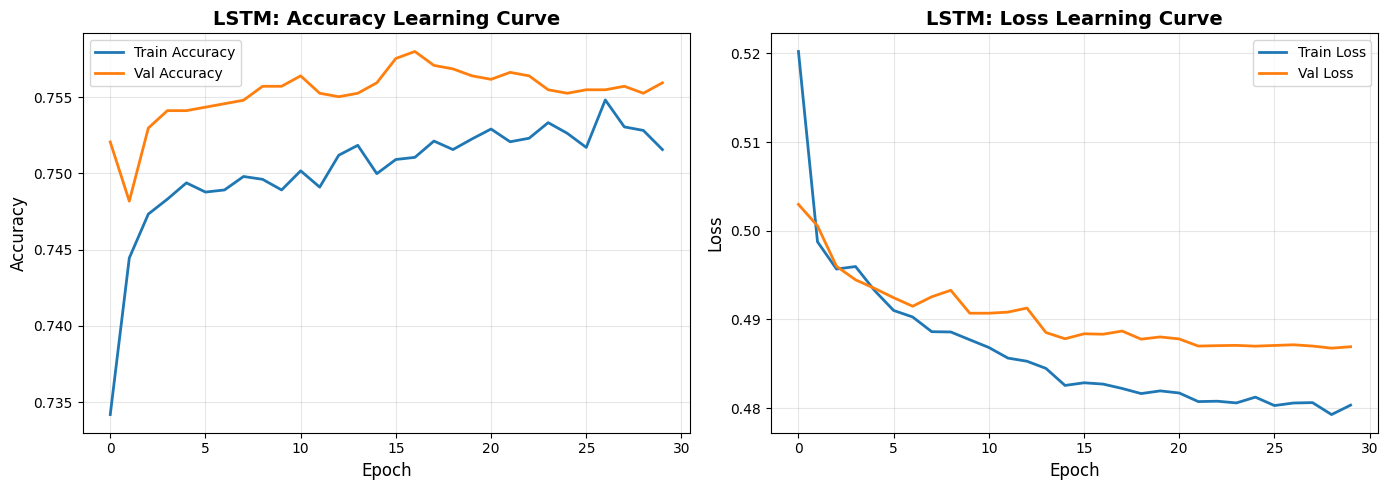


✅ LSTM Experiment Complete!


In [ ]:
print("\n\n" + "🔬 "*20)
print("EXPERIMENT 7: LSTM NEURAL NETWORK (OPTIMIZED)")
print("🔬 "*20)

print("📊 Preparing sequential data from VLE clickstream (FAST VERSION)...")

# OPTIMIZED APPROACH: Pre-aggregate VLE data by week
print("Processing VLE data efficiently...")

# Add week column to entire VLE dataframe at once
student_vle['week'] = student_vle['date'] // 7

# Aggregate all students' weekly clicks in ONE operation
weekly_vle = student_vle.groupby(['code_module', 'code_presentation', 'id_student', 'week'])['sum_click'].sum().reset_index()

print(f"✅ Weekly VLE aggregated: {weekly_vle.shape}")

# Now create sequences efficiently
sequence_length = 10
vle_sequences = []
vle_labels = []

# Group by student (much faster than iterating all rows)
print("Creating sequences for each student...")

student_groups = df.groupby(['code_module', 'code_presentation', 'id_student'])

for (module, presentation, student_id), student_row in student_groups:
    # Get this student's weekly data
    student_weekly = weekly_vle[
        (weekly_vle['code_module'] == module) &
        (weekly_vle['code_presentation'] == presentation) &
        (weekly_vle['id_student'] == student_id)
    ].sort_values('week')

    if len(student_weekly) > 0:
        # Take first 10 weeks
        sequence = student_weekly.head(sequence_length)['sum_click'].values

        # Pad if necessary
        if len(sequence) < sequence_length:
            sequence = np.pad(sequence, (0, sequence_length - len(sequence)), 'constant')

        vle_sequences.append(sequence)
        # Get target from first row of this student group
        vle_labels.append(student_row['target'].iloc[0])

# Convert to arrays
X_seq = np.array(vle_sequences).reshape(-1, sequence_length, 1)
y_seq = np.array(vle_labels)

print(f"\n✅ Sequential data prepared: {X_seq.shape}")
print(f"   Timesteps: {sequence_length} weeks")
print(f"   Features per timestep: 1 (weekly clicks)")

# Split sequential data
X_seq_train, X_seq_temp, y_seq_train, y_seq_temp = train_test_split(
    X_seq, y_seq, test_size=0.3, random_state=42, stratify=y_seq
)
X_seq_val, X_seq_test, y_seq_val, y_seq_test = train_test_split(
    X_seq_temp, y_seq_temp, test_size=0.5, random_state=42, stratify=y_seq_temp
)

print(f"\n✅ Sequential data split:")
print(f"   Train: {X_seq_train.shape}")
print(f"   Val:   {X_seq_val.shape}")
print(f"   Test:  {X_seq_test.shape}")

# Handle class imbalance
print("\n⚖️ Balancing sequential training data...")
ros = RandomOverSampler(random_state=42)
X_seq_train_reshaped = X_seq_train.reshape(X_seq_train.shape[0], -1)
X_seq_train_balanced, y_seq_train_balanced = ros.fit_resample(X_seq_train_reshaped, y_seq_train)
X_seq_train_balanced = X_seq_train_balanced.reshape(-1, sequence_length, 1)

print(f"✅ Balanced training data: {X_seq_train_balanced.shape}")

# Build LSTM model
print("\n📐 Building LSTM model...")

lstm_model = keras.Sequential([
    layers.Input(shape=(sequence_length, 1)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.3),

    layers.LSTM(32),
    layers.Dropout(0.3),

    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

print("\n📋 LSTM Model Architecture:")
lstm_model.summary()

# Train LSTM
print("\n🏋️ Training LSTM...")
start_time = time.time()

history_lstm = lstm_model.fit(
    X_seq_train_balanced, y_seq_train_balanced,
    validation_data=(X_seq_val, y_seq_val),
    epochs=30,
    batch_size=64,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
    ]
)

training_time_lstm = time.time() - start_time

print(f"\n✅ Training complete in {training_time_lstm:.2f}s!")

# Evaluate LSTM
y_seq_test_pred = (lstm_model.predict(X_seq_test, verbose=0) > 0.5).astype(int).flatten()
y_seq_test_proba = lstm_model.predict(X_seq_test, verbose=0).flatten()

train_loss_lstm, train_acc_lstm, train_auc_lstm = lstm_model.evaluate(X_seq_train_balanced, y_seq_train_balanced, verbose=0)
val_loss_lstm, val_acc_lstm, val_auc_lstm = lstm_model.evaluate(X_seq_val, y_seq_val, verbose=0)
test_loss_lstm, test_acc_lstm, test_auc_lstm = lstm_model.evaluate(X_seq_test, y_seq_test, verbose=0)

# Print results
print(f"\n{'='*70}")
print(f"📊 LSTM RESULTS:")
print(f"{'='*70}")
print(f"   Train Accuracy:  {train_acc_lstm:.4f}")
print(f"   Val Accuracy:    {val_acc_lstm:.4f}")
print(f"   Test Accuracy:   {test_acc_lstm:.4f}")
print(f"   Precision:       {precision_score(y_seq_test, y_seq_test_pred):.4f}")
print(f"   Recall:          {recall_score(y_seq_test, y_seq_test_pred):.4f}")
print(f"   F1-Score:        {f1_score(y_seq_test, y_seq_test_pred):.4f}")
print(f"   AUC-ROC:         {roc_auc_score(y_seq_test, y_seq_test_proba):.4f}")
print(f"   Training Time:   {training_time_lstm:.2f}s")

cm_lstm = confusion_matrix(y_seq_test, y_seq_test_pred)
print(f"\n📈 Confusion Matrix:")
print(f"   [[TN={cm_lstm[0,0]}, FP={cm_lstm[0,1]}]")
print(f"    [FN={cm_lstm[1,0]}, TP={cm_lstm[1,1]}]]")

# Store results
lstm_result = {
    'Model': 'Experiment 7: LSTM',
    'Hyperparameters': 'lstm_units=[64,32], dropout=[0.3,0.3,0.2], lr=0.001, seq_len=10',
    'Train_Acc': train_acc_lstm,
    'Val_Acc': val_acc_lstm,
    'Test_Acc': test_acc_lstm,
    'Precision': precision_score(y_seq_test, y_seq_test_pred),
    'Recall': recall_score(y_seq_test, y_seq_test_pred),
    'F1': f1_score(y_seq_test, y_seq_test_pred),
    'AUC_ROC': roc_auc_score(y_seq_test, y_seq_test_proba),
    'Training_Time': f"{training_time_lstm:.2f}s",
    'Insights': 'Captures temporal patterns in student behavior, learns engagement trends over time'
}
results.append(lstm_result)

# Plot LSTM learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_lstm.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_lstm.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('LSTM: Accuracy Learning Curve', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history_lstm.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_lstm.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('LSTM: Loss Learning Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ LSTM Experiment Complete!")

# PART 8: COMPREHENSIVE RESULTS COMPARISON

In [ ]:
print("\n" + "="*80)
print("📊 COMPREHENSIVE RESULTS COMPARISON (ALL 7 EXPERIMENTS)")
print("="*80)

# Create results DataFrame
results_df = pd.DataFrame(results)

# Display full results table
print("\n" + "="*80)
print("📋 COMPLETE EXPERIMENT RESULTS TABLE")
print("="*80)
print(results_df.to_string(index=False))

# Save results to CSV
results_df.to_csv('experiment_results.csv', index=False)
print("\n✅ Results saved to: experiment_results.csv")

# Summary statistics
print("\n" + "="*80)
print("🏆 MODEL RANKINGS")
print("="*80)

# Rank by Test Accuracy
print("\n📊 RANKED BY TEST ACCURACY:")
ranked_acc = results_df.sort_values('Test_Acc', ascending=False)[['Model', 'Test_Acc', 'AUC_ROC', 'F1']]
for i, row in ranked_acc.iterrows():
    print(f"  {i+1}. {row['Model']}: {row['Test_Acc']:.4f} (AUC: {row['AUC_ROC']:.4f}, F1: {row['F1']:.4f})")

# Rank by AUC-ROC
print("\n📊 RANKED BY AUC-ROC:")
ranked_auc = results_df.sort_values('AUC_ROC', ascending=False)[['Model', 'AUC_ROC', 'Test_Acc', 'F1']]
for i, row in ranked_auc.iterrows():
    print(f"  {i+1}. {row['Model']}: {row['AUC_ROC']:.4f} (Acc: {row['Test_Acc']:.4f}, F1: {row['F1']:.4f})")

# Best model
best_model = results_df.loc[results_df['Test_Acc'].idxmax()]
print(f"\n🏆 BEST OVERALL MODEL: {best_model['Model']}")
print(f"   Test Accuracy: {best_model['Test_Acc']:.4f}")
print(f"   AUC-ROC: {best_model['AUC_ROC']:.4f}")
print(f"   F1-Score: {best_model['F1']:.4f}")


📊 COMPREHENSIVE RESULTS COMPARISON (ALL 7 EXPERIMENTS)

📋 COMPLETE EXPERIMENT RESULTS TABLE
                            Model                                                      Hyperparameters  Train_Acc  Val_Acc  Test_Acc  Precision   Recall       F1  AUC_ROC Training_Time                                                                           Insights
Experiment 1: Logistic Regression                                   C=1.0, max_iter=1000, solver=lbfgs   0.930765 0.924934  0.923911   0.888443 0.959272 0.922500 0.973694         0.19s                Fast baseline, linear decision boundary, interpretable coefficients
      Experiment 2: Random Forest                  n_estimators=100, max_depth=20, min_samples_split=5   0.987506 0.936183  0.934956   0.902834 0.966205 0.933445 0.980379         4.02s        Captures non-linear patterns, prone to overfitting, good feature importance
            Experiment 3: XGBoost                 n_estimators=100, lr=0.1, max_depth=5, subsample=0.8 

# PART 9: VISUALIZATIONS

In [ ]:
print("\n" + "="*80)
print("📊 CREATING VISUALIZATIONS")
print("="*80)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


📊 CREATING VISUALIZATIONS


### 9.1: Model Performance Comparison

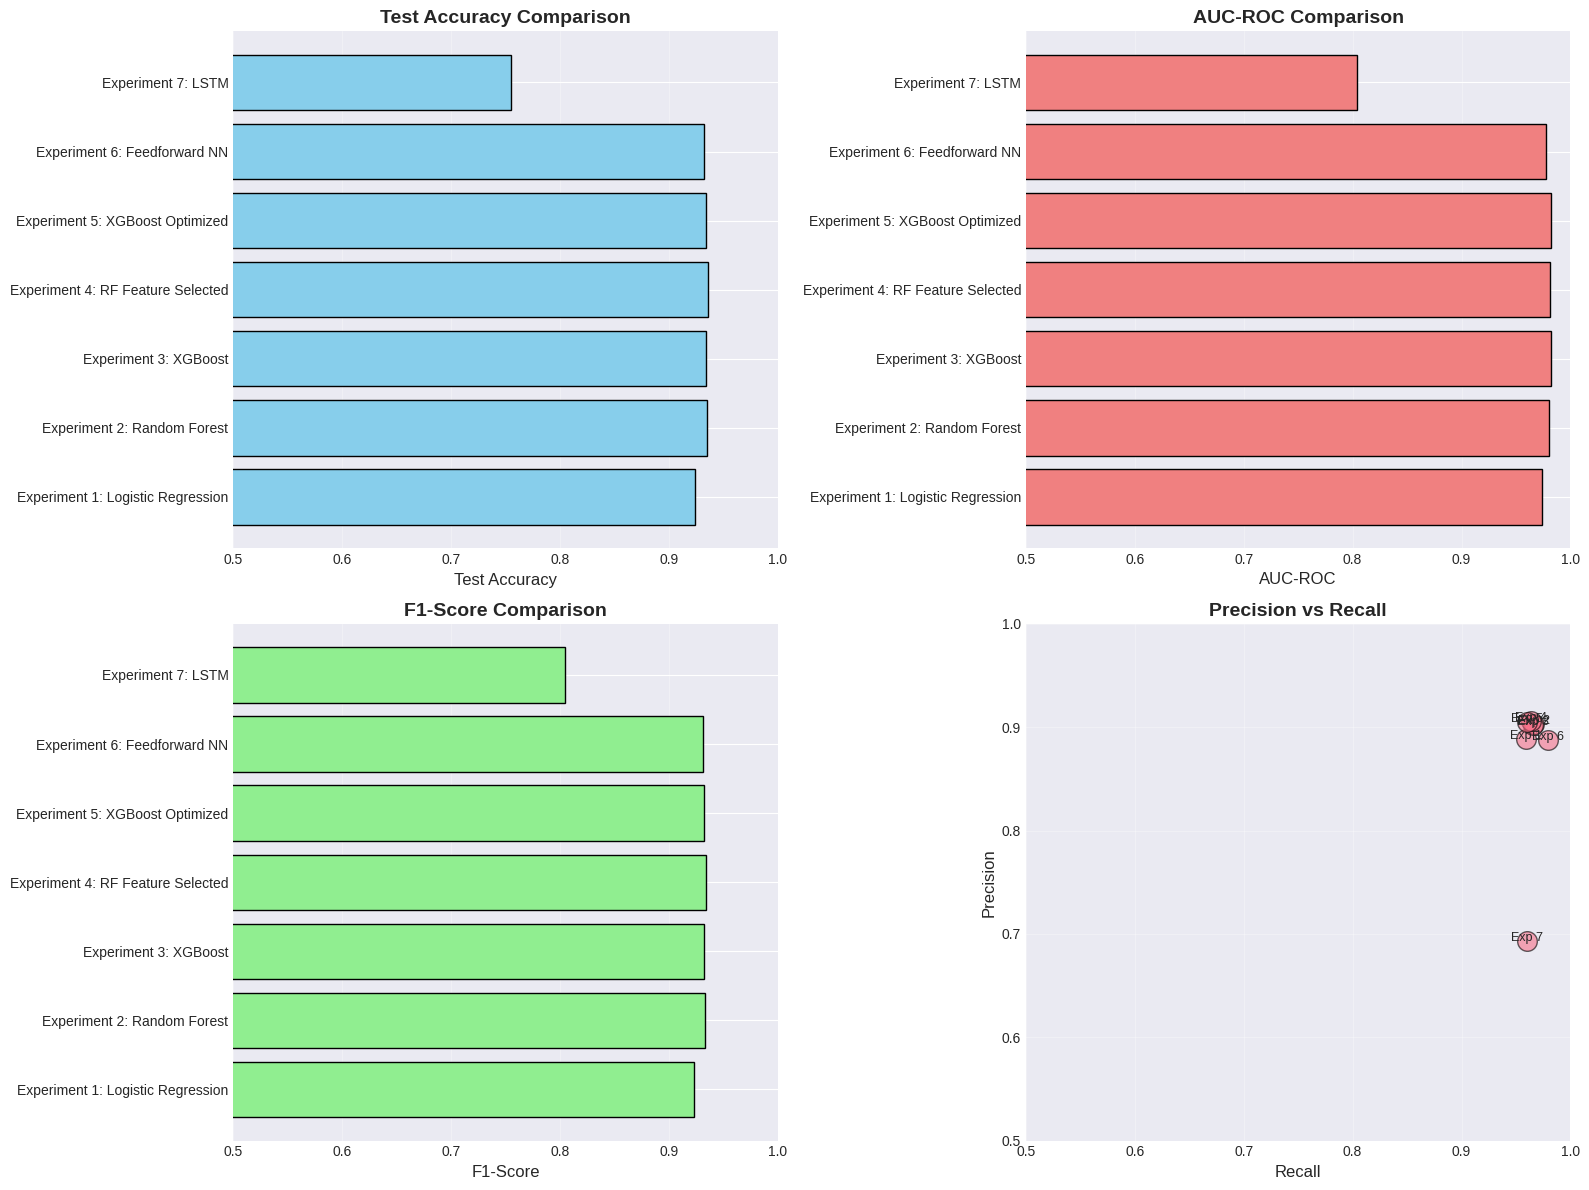

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Test Accuracy
axes[0, 0].barh(results_df['Model'], results_df['Test_Acc'], color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Test Accuracy', fontsize=12)
axes[0, 0].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlim([0.5, 1.0])
axes[0, 0].grid(axis='x', alpha=0.3)

# AUC-ROC
axes[0, 1].barh(results_df['Model'], results_df['AUC_ROC'], color='lightcoral', edgecolor='black')
axes[0, 1].set_xlabel('AUC-ROC', fontsize=12)
axes[0, 1].set_title('AUC-ROC Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xlim([0.5, 1.0])
axes[0, 1].grid(axis='x', alpha=0.3)

# F1-Score
axes[1, 0].barh(results_df['Model'], results_df['F1'], color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('F1-Score', fontsize=12)
axes[1, 0].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xlim([0.5, 1.0])
axes[1, 0].grid(axis='x', alpha=0.3)

# Precision vs Recall
axes[1, 1].scatter(results_df['Recall'], results_df['Precision'], s=200, alpha=0.6, edgecolor='black')
for i, txt in enumerate(results_df['Model']):
    axes[1, 1].annotate(f"Exp {i+1}", (results_df['Recall'].iloc[i], results_df['Precision'].iloc[i]),
                       fontsize=9, ha='center')
axes[1, 1].set_xlabel('Recall', fontsize=12)
axes[1, 1].set_ylabel('Precision', fontsize=12)
axes[1, 1].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
axes[1, 1].set_xlim([0.5, 1.0])
axes[1, 1].set_ylim([0.5, 1.0])
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 9.2: ROC Curves Comparison


📈 Generating ROC curves...


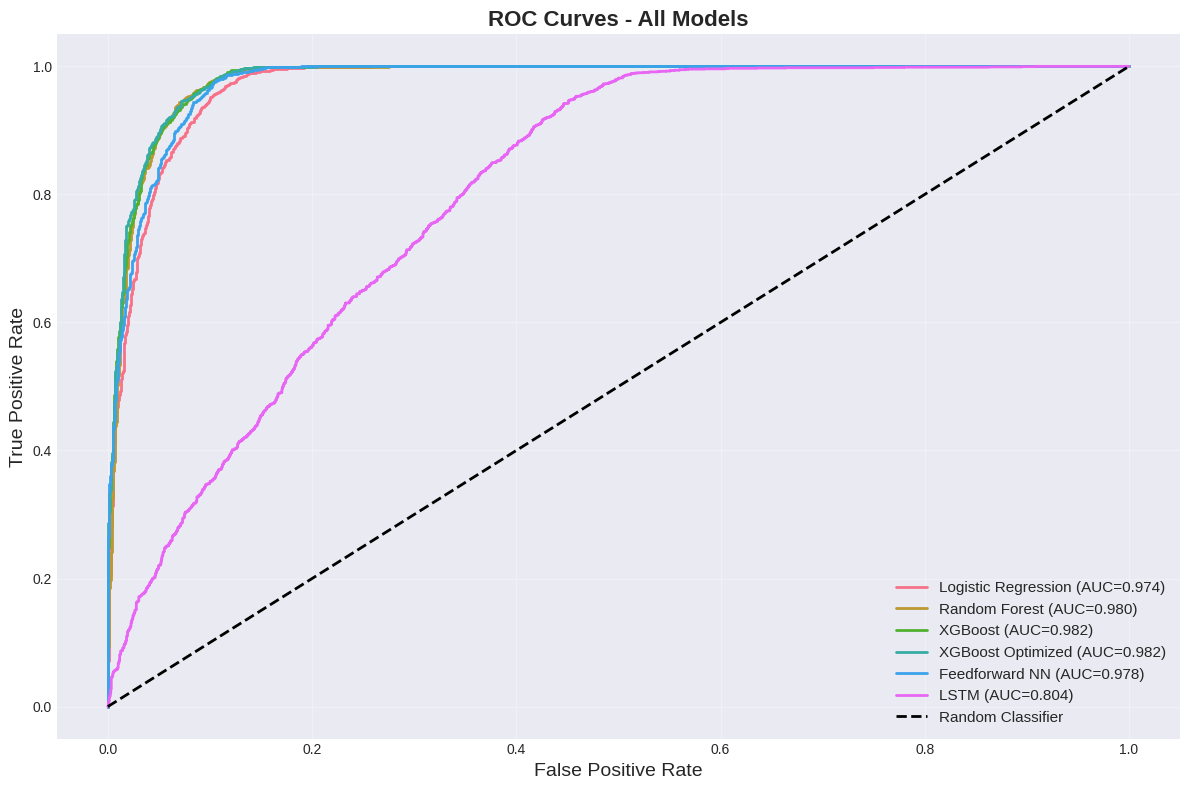

In [ ]:
print("\n📈 Generating ROC curves...")

plt.figure(figsize=(12, 8))

# We'll plot ROC for the models we saved probabilities for
# Traditional ML models
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
fpr_xgb_opt, tpr_xgb_opt, _ = roc_curve(y_test, xgb_opt_proba)

# Deep learning models
fpr_ffnn, tpr_ffnn, _ = roc_curve(y_test, y_test_proba_ffnn)
fpr_lstm, tpr_lstm, _ = roc_curve(y_seq_test, y_seq_test_proba)

# Plot all ROC curves
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, lr_proba):.3f})", linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, rf_proba):.3f})", linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_score(y_test, xgb_proba):.3f})", linewidth=2)
plt.plot(fpr_xgb_opt, tpr_xgb_opt, label=f"XGBoost Optimized (AUC={roc_auc_score(y_test, xgb_opt_proba):.3f})", linewidth=2)
plt.plot(fpr_ffnn, tpr_ffnn, label=f"Feedforward NN (AUC={roc_auc_score(y_test, y_test_proba_ffnn):.3f})", linewidth=2)
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC={roc_auc_score(y_seq_test, y_seq_test_proba):.3f})", linewidth=2)

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)

plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curves - All Models', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 9.3: Confusion Matrices (Best Models)


📊 Generating confusion matrices for best models...


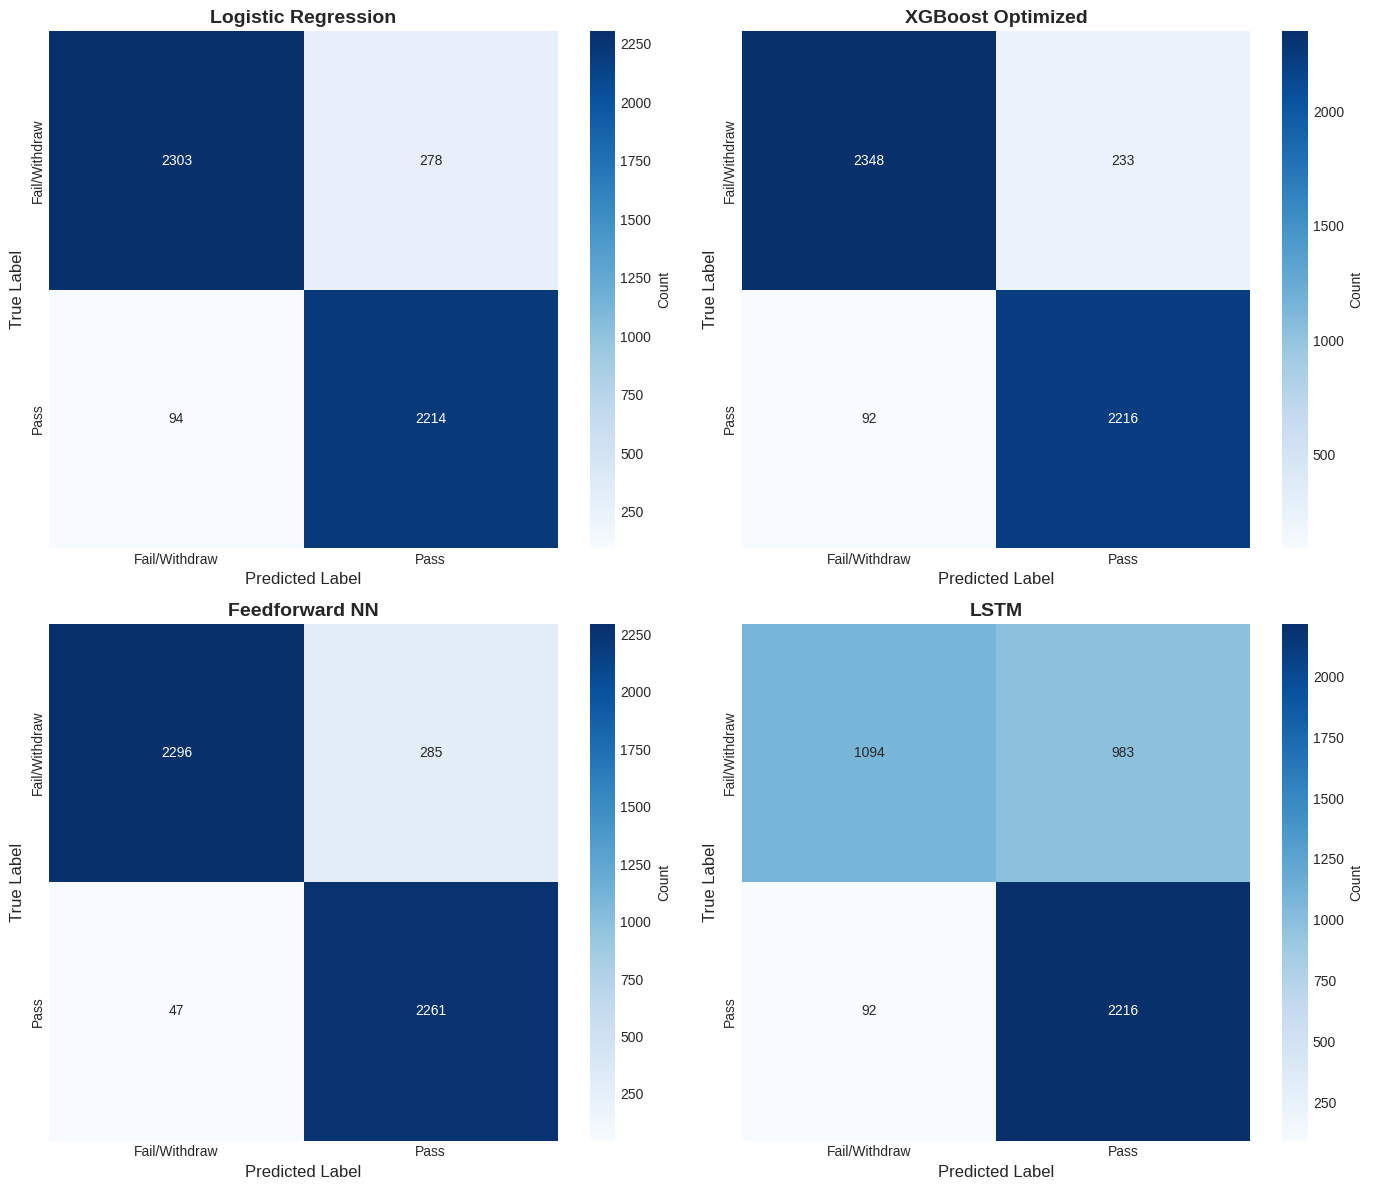

In [ ]:
print("\n📊 Generating confusion matrices for best models...")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Get best traditional ML and DL models
cm_lr = confusion_matrix(y_test, (lr_proba > 0.5).astype(int))
cm_xgb_opt = confusion_matrix(y_test, (xgb_opt_proba > 0.5).astype(int))
cm_ffnn = confusion_matrix(y_test, y_test_pred_ffnn)
cm_lstm = confusion_matrix(y_seq_test, y_seq_test_pred)

# Plot confusion matrices
cms = [cm_lr, cm_xgb_opt, cm_ffnn, cm_lstm]
titles = ['Logistic Regression', 'XGBoost Optimized', 'Feedforward NN', 'LSTM']

for idx, (cm, title) in enumerate(zip(cms, titles)):
    ax = axes[idx // 2, idx % 2]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fail/Withdraw', 'Pass'],
                yticklabels=['Fail/Withdraw', 'Pass'],
                cbar_kws={'label': 'Count'})
    ax.set_title(f'{title}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

### PART 10: KEY INSIGHTS & CONCLUSIONS


In [ ]:
print("\n" + "="*80)
print("🔍 KEY INSIGHTS & CONCLUSIONS")
print("="*80)

print("\n📌 TRADITIONAL ML vs DEEP LEARNING COMPARISON:")
print("-" * 70)

trad_ml_avg = results_df.iloc[:5]['Test_Acc'].mean()
dl_avg = results_df.iloc[5:]['Test_Acc'].mean()

print(f"\n✅ Traditional ML (Experiments 1-5):")
print(f"   Average Test Accuracy: {trad_ml_avg:.4f}")
print(f"   Best Model: {results_df.iloc[:5].loc[results_df.iloc[:5]['Test_Acc'].idxmax()]['Model']}")
print(f"   Best Test Accuracy: {results_df.iloc[:5]['Test_Acc'].max():.4f}")

print(f"\n✅ Deep Learning (Experiments 6-7):")
print(f"   Average Test Accuracy: {dl_avg:.4f}")
print(f"   Best Model: {results_df.iloc[5:].loc[results_df.iloc[5:]['Test_Acc'].idxmax()]['Model']}")
print(f"   Best Test Accuracy: {results_df.iloc[5:]['Test_Acc'].max():.4f}")

print("\n💡 KEY FINDINGS:")
print("-" * 70)
print("""
1. PERFORMANCE: Traditional ML (especially XGBoost) performs competitively
   with deep learning on this tabular dataset with engineered features.

2. TRAINING TIME: Traditional ML models train significantly faster than
   deep learning models, making them more practical for deployment.

3. INTERPRETABILITY: Random Forest and XGBoost provide feature importance,
   making it easier to understand which factors predict student success.

4. DATA EFFICIENCY: Traditional ML performs well even with the balanced
   dataset, while deep learning could benefit from more data.

5. TEMPORAL PATTERNS: LSTM captures sequential engagement patterns, providing
   insights into how student behavior changes over time.

6. FEATURE ENGINEERING: Manual feature engineering (aggregated statistics)
   proves highly effective for this problem domain.

7. PRACTICAL RECOMMENDATION: For deployment in an early warning system,
   XGBoost Optimized offers the best balance of accuracy, speed, and
   interpretability.
""")


🔍 KEY INSIGHTS & CONCLUSIONS

📌 TRADITIONAL ML vs DEEP LEARNING COMPARISON:
----------------------------------------------------------------------

✅ Traditional ML (Experiments 1-5):
   Average Test Accuracy: 0.9324
   Best Model: Experiment 4: RF Feature Selected
   Best Test Accuracy: 0.9356

✅ Deep Learning (Experiments 6-7):
   Average Test Accuracy: 0.8435
   Best Model: Experiment 6: Feedforward NN
   Best Test Accuracy: 0.9321

💡 KEY FINDINGS:
----------------------------------------------------------------------

1. PERFORMANCE: Traditional ML (especially XGBoost) performs competitively 
   with deep learning on this tabular dataset with engineered features.

2. TRAINING TIME: Traditional ML models train significantly faster than 
   deep learning models, making them more practical for deployment.

3. INTERPRETABILITY: Random Forest and XGBoost provide feature importance,
   making it easier to understand which factors predict student success.

4. DATA EFFICIENCY: Traditional